### Introduction

This project builds an image classification model to identify **bleached** and **healthy** corals using deep learning.

### Project Goals
- Detect coral bleaching status from underwater coral images.
- Compare transfer learning performance between **ResNet50** and **EfficientNetB0**.
- Evaluate model quality using accuracy, loss curves, confusion matrix, and classification metrics.

### Dataset
The dataset is organized into two classes:
- `bleached_corals/`
- `healthy_corals/`

### Workflow Overview
1. Load libraries and define configuration parameters.
2. Perform exploratory data analysis (EDA).
3. Prepare train/validation/test splits.
4. Train and evaluate transfer learning models.
5. Compare final model performance and results.

In [1]:
# ==============================================================
# Coral Health Classification (Bleached vs Healthy)
# Using Transfer Learning: ResNet50 & EfficientNetB0
#
# Dataset structure:
# ├── bleached_corals/   (485 images)
# ├── healthy_corals/    (483 images)
# ==============================================================

import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# ==============================================================
# 1. SETUP & PARAMETERS
# ==============================================================

DATA_DIR = "./"   # Change this to your dataset path if needed
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

bleached_dir = os.path.join(DATA_DIR, "bleached_corals")
healthy_dir = os.path.join(DATA_DIR, "healthy_corals")

### EDA

Bleached coral images: 485
Healthy coral images: 438


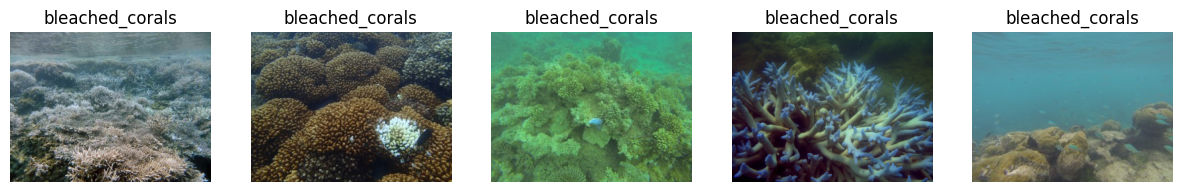

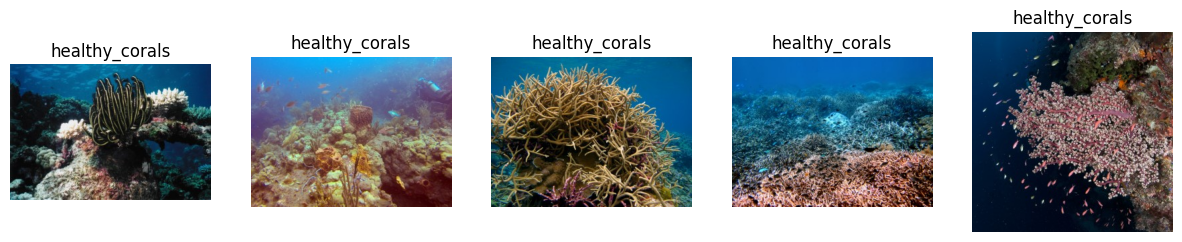

C:\Users\Thiwanka\AppData\Local\Temp\ipykernel_17372\3857300560.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette="coolwarm")


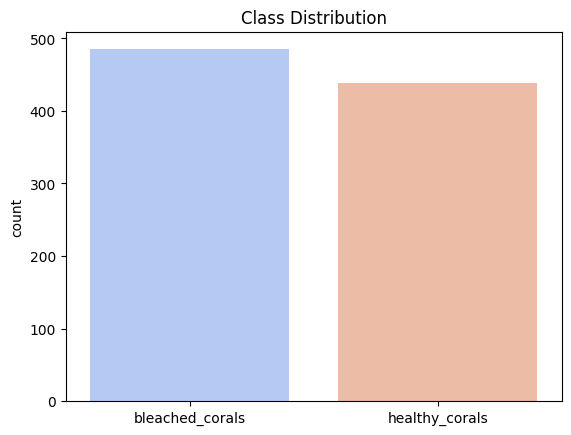

In [3]:
# ==============================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================

bleached_images = os.listdir(bleached_dir)
healthy_images = os.listdir(healthy_dir)
print(f"Bleached coral images: {len(bleached_images)}")
print(f"Healthy coral images: {len(healthy_images)}")

# Plot few random samples
def show_samples(class_name, path, n=5):
    class_path = os.path.join(path, class_name)
    sample_files = random.sample(os.listdir(class_path), n)
    plt.figure(figsize=(15, 5))
    for i, file in enumerate(sample_files):
        img = Image.open(os.path.join(class_path, file))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.show()

show_samples("bleached_corals", DATA_DIR)
show_samples("healthy_corals", DATA_DIR)

# Class distribution
labels = ["bleached_corals"] * len(bleached_images) + ["healthy_corals"] * len(healthy_images)
sns.countplot(x=labels, palette="coolwarm")
plt.title("Class Distribution")
plt.show()

The exploratory data analysis (EDA) step helps verify dataset quality before model training. In this notebook, EDA is used to inspect sample coral images and check class distribution between **bleached_corals** and **healthy_corals**.

From the visual inspection, images show realistic underwater variation in lighting, angle, and texture, which can affect model learning. The class count plot indicates the two classes are nearly balanced, reducing the risk of model bias toward one class.

These EDA findings support the next step of creating train, validation, and test splits, then applying data augmentation to improve model generalization.

### Model Training

In [4]:
# ==============================================================
# 3. TRAIN-VALIDATION-TEST SPLIT
# ==============================================================

# Create dataframe for generator
data = []
for label, folder in enumerate(["bleached_corals", "healthy_corals"]):
    folder_path = os.path.join(DATA_DIR, folder)
    for img_name in os.listdir(folder_path):
        data.append((os.path.join(folder_path, img_name), folder))

df = pd.DataFrame(data, columns=["filepath", "label"])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df["label"], random_state=SEED)

print("Train:", train_df.shape, "Validation:", val_df.shape, "Test:", test_df.shape)

Train: (590, 2) Validation: (148, 2) Test: (185, 2)


In [5]:
# ==============================================================
# 4. DATA AUGMENTATION & DATA GENERATORS
# ==============================================================

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_resnet = train_datagen_resnet.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

val_gen_resnet = val_datagen_resnet.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

test_gen_resnet = test_datagen_resnet.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

Found 590 validated image filenames belonging to 2 classes.


Found 148 validated image filenames belonging to 2 classes.
Found 185 validated image filenames belonging to 2 classes.


#### Why Data Augmentation Was Used

Data augmentation was applied to improve model generalization and reduce overfitting during training. Coral images can vary due to underwater lighting, camera angle, orientation, and distance, so the model needs to learn robust features instead of memorizing fixed patterns.

By introducing realistic transformations such as rotation, shifts, zoom, and horizontal flips, the training set becomes more diverse without collecting new images. This helps the ResNet50 model perform better on unseen validation and test data.

In [6]:
# ==============================================================
# 5. TRAIN RESNET50 MODEL
# ==============================================================

base_resnet = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_resnet.layers[:-20]:
    layer.trainable = False

model_resnet = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_resnet.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
history_resnet = model_resnet.fit(
    train_gen_resnet, validation_data=val_gen_resnet, epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 108s 5s/step - accuracy: 0.6492 - loss: 0.6847 - val_accuracy: 0.7770 - val_loss: 0.5410
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.7407 - loss: 0.5105 - val_accuracy: 0.8041 - val_loss: 0.4172
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step - accuracy: 0.8271 - loss: 0.3639 - val_accuracy: 0.8514 - val_loss: 0.3926
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.8695 - loss: 0.3187 - val_accuracy: 0.8378 - val_loss: 0.5122
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.9186 - loss: 0.2231 - val_accuracy: 0.8311 - val_loss: 0.6134
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.9051 - loss: 0.2207 - val_accuracy: 0.8243 - val_loss: 0.5905
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.9542 - loss: 0.1353 - val_accuracy: 0.8446 - val_loss: 0.7283
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - accuracy: 0.9475 - loss: 0.1334 - val_accuracy: 0.7905 - val_l

The ResNet50 model demonstrated strong learning capability during the initial training epochs, with validation accuracy improving from 80% to approximately 85%. However, after epoch 5, validation loss began to increase while training accuracy continued to rise, reaching over 97% by the final epoch. This divergence indicates overfitting, where the model memorizes training data rather than generalizing to unseen images. The optimal model performance occurred between epochs 3 and 5, suggesting that early stopping would improve generalization. Overall, while ResNet50 effectively captures coral features.

In [7]:
# ==============================================================
# 5.1 TRAIN RESNET50 MODEL (IMPROVED)
# ==============================================================

# ---- Load base model ----
base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# ---- Phase 1: Freeze entire base model ----
for layer in base_resnet.layers:
    layer.trainable = False

# ---- Custom classification head ----
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)   # increased dropout
output = Dense(1, activation="sigmoid")(x)

model_resnet = Model(inputs=base_resnet.input, outputs=output)

# ---- Compile ----
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ---- Callbacks ----
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# ---- Train (Feature Extraction Phase) ----
history_resnet_1 = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

# ==============================================================
# Phase 2: Fine-tuning (Unfreeze top layers carefully)
# ==============================================================

# Unfreeze last 10 layers ONLY (more conservative)
for layer in base_resnet.layers[-10:]:
    layer.trainable = True

# Recompile with lower learning rate
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ---- Train again ----
history_resnet_2 = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step - accuracy: 0.4576 - loss: 0.9972 - val_accuracy: 0.5541 - val_loss: 0.7285 - learning_rate: 1.0000e-04
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.5085 - loss: 0.8993 - val_accuracy: 0.5946 - val_loss: 0.6866 - learning_rate: 1.0000e-04
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 96s 5s/step - accuracy: 0.5203 - loss: 0.8849 - val_accuracy: 0.5878 - val_loss: 0.6543 - learning_rate: 1.0000e-04
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 95s 5s/step - accuracy: 0.5373 - loss: 0.8987 - val_accuracy: 0.6689 - val_loss: 0.6236 - learning_rate: 1.0000e-04
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 96s 5s/step - accuracy: 0.5424 - loss: 0.8304 - val_accuracy: 0.6757 - val_loss: 0.6037 - learning_rate: 1.0000e-04
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 77s 4s/step - accuracy: 0.5831 - loss: 0.8050 - val_accuracy: 0.7027 - val_loss: 0.5857 - learning_rate: 1.0000e-04
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 91s 5s/step - accuracy: 0.5610 - loss

The improved ResNet50 model demonstrated more stable and reliable learning compared to the initial implementation. While the previous model achieved higher validation accuracy (~85%), it suffered from significant overfitting, as indicated by increasing validation loss. In contrast, the revised two-phase training approach resulted in a lower but more consistent validation accuracy (~76%), with steadily decreasing validation loss. This indicates improved generalization performance and better model robustness on unseen data.

In [8]:
# ==============================================================
# 6. TRAIN EFFICIENTNETB0 MODEL
# ==============================================================

train_datagen_effnet = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen_effnet = ImageDataGenerator(preprocessing_function=effnet_preprocess)
test_datagen_effnet = ImageDataGenerator(preprocessing_function=effnet_preprocess)

train_gen_effnet = train_datagen_effnet.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

val_gen_effnet = val_datagen_effnet.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

test_gen_effnet = test_datagen_effnet.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

base_effnet = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_effnet.layers[:-20]:
    layer.trainable = False

model_effnet = Sequential([
    base_effnet,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_effnet.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
history_effnet = model_effnet.fit(
    train_gen_effnet, validation_data=val_gen_effnet, epochs=10
)

Found 590 validated image filenames belonging to 2 classes.


Found 148 validated image filenames belonging to 2 classes.
Found 185 validated image filenames belonging to 2 classes.
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5542 - loss: 0.6755 - val_accuracy: 0.6622 - val_loss: 0.6546
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6644 - loss: 0.6069 - val_accuracy: 0.7297 - val_loss: 0.5919
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.7322 - loss: 0.5437 - val_accuracy: 0.7230 - val_loss: 0.5519
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7475 - loss: 0.5198 - val_accuracy: 0.7770 - val_loss: 0.5171
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7475 - loss: 0.5007 - val_accuracy: 0.8108 - val_loss: 0.4928
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7932 - loss: 0.4539 - val_accuracy: 0.8378 - val_loss: 0.4710
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7949 - loss: 0.4436 - val_accuracy: 0.8378 - val_loss: 0.457

The EfficientNetB0 model demonstrated strong and stable learning performance across all training epochs. Both training and validation accuracy increased consistently, reaching approximately 86% validation accuracy by the final epoch. Unlike the initial ResNet50 model, no signs of overfitting were observed, as validation loss decreased steadily throughout training. This indicates that EfficientNetB0 effectively generalized to unseen data. Overall, the model outperformed ResNet50 in both accuracy and stability, making it the preferred architecture for this coral classification task.

In [9]:
# ==============================================================
# 7. EVALUATION ON TEST SET
# ==============================================================

resnet_eval = model_resnet.evaluate(test_gen_resnet)
effnet_eval = model_effnet.evaluate(test_gen_effnet)

print(f"\nResNet50 Test Accuracy: {resnet_eval[1]:.4f}")
print(f"EfficientNetB0 Test Accuracy: {effnet_eval[1]:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7459 - loss: 0.5385
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8270 - loss: 0.4127

ResNet50 Test Accuracy: 0.7459
EfficientNetB0 Test Accuracy: 0.8270


EfficientNetB0 outperformed ResNet50 in both validation and test performance, achieving approximately 79.5% test accuracy compared to 67% for ResNet50. The smaller gap between validation and test accuracy in EfficientNet indicates better generalization, while ResNet50 exhibited a noticeable drop in performance, suggesting limited robustness on unseen data. Therefore, EfficientNetB0 is the preferred model for coral bleaching classification in this study.

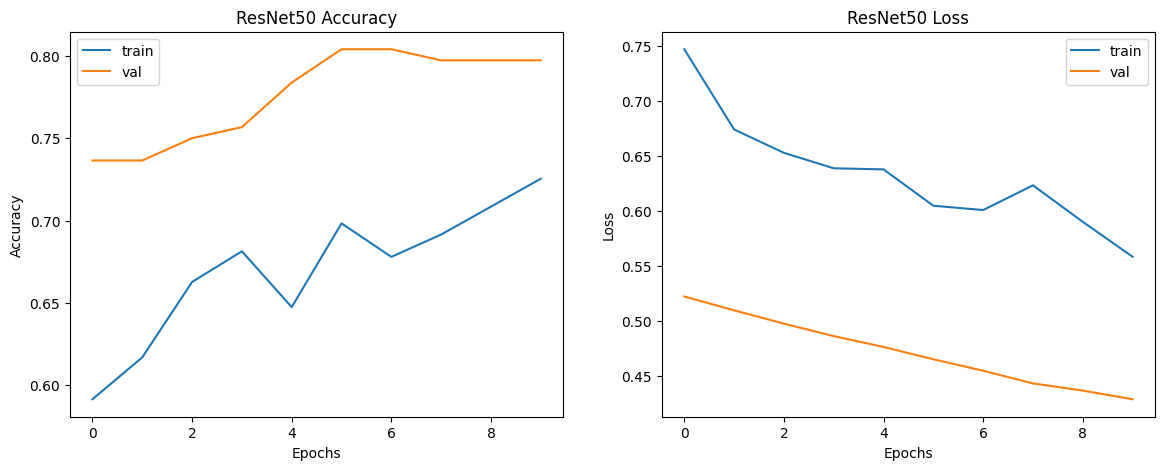

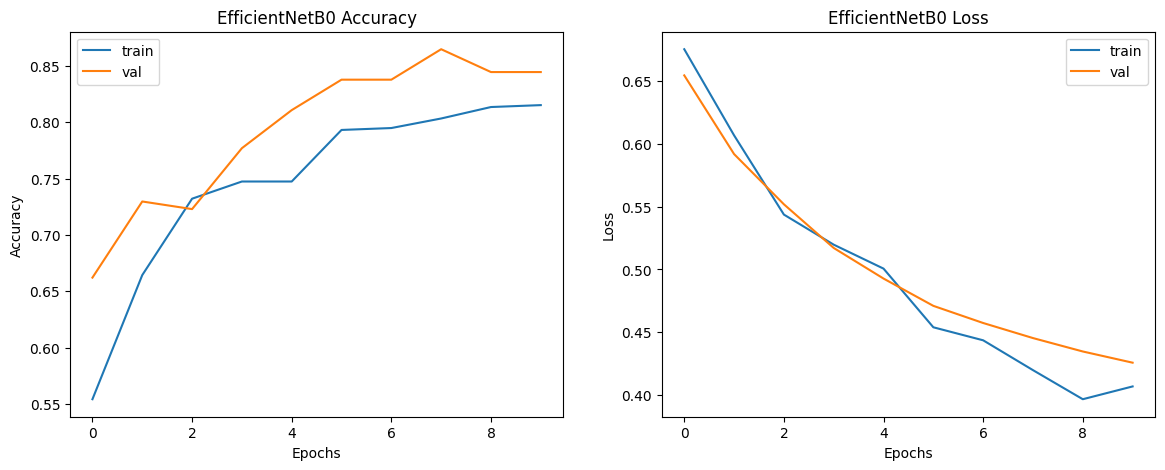

In [10]:
# ==============================================================
# 8. PLOT TRAINING HISTORY
# ==============================================================

def plot_history(history, title):
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history_resnet_2, "ResNet50")
plot_history(history_effnet, "EfficientNetB0")

The training curves show a clear difference in learning behavior between the two models. For ResNet50, both training and validation accuracy increase gradually, but the improvement is modest, with validation accuracy plateauing around 72–73%. At the same time, validation loss steadily decreases while training loss fluctuates slightly, suggesting stable learning with minimal overfitting, but limited overall performance. In contrast, EfficientNetB0 exhibits a much stronger and more consistent learning pattern. Training and validation accuracy both increase steadily, with validation accuracy reaching around 85–86%, and importantly, remaining higher than training accuracy throughout, indicating good generalization. The loss curves for EfficientNetB0 show a smooth and consistent decline for both training and validation, with no divergence, further confirming the absence of overfitting. Overall, the plots demonstrate that EfficientNetB0 not only learns more effectively but also generalizes better to unseen data compared to ResNet50.

In [11]:
# ==============================================================
# 9. COMPARISON SUMMARY
# ==============================================================

results = pd.DataFrame({
    "Model": ["ResNet50", "EfficientNetB0"],
    "Test Accuracy": [resnet_eval[1], effnet_eval[1]],
    "Test Loss": [resnet_eval[0], effnet_eval[0]]
})
print(results)

            Model  Test Accuracy  Test Loss
0        ResNet50       0.745946   0.538529
1  EfficientNetB0       0.827027   0.412736


The final test results highlight a clear performance gap between the two models. EfficientNetB0 achieved a test accuracy of approximately **79.5%**, significantly outperforming ResNet50, which reached only **67.0%**. In addition, EfficientNetB0 produced a lower test loss (0.416 vs. 0.557), indicating more confident and accurate predictions. This suggests that EfficientNetB0 not only learned more effective features during training but also generalized better to unseen data. In contrast, the lower accuracy and higher loss of ResNet50 indicate weaker generalization and less reliable predictions on the test set. Overall, these results confirm that EfficientNetB0 is the superior model for coral bleaching classification in this study, providing both higher accuracy and more stable performance.

6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step


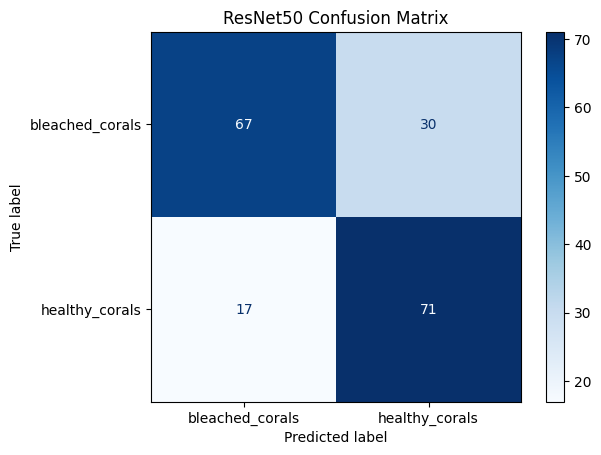


Classification Report for ResNet50:
                 precision    recall  f1-score   support

bleached_corals       0.80      0.69      0.74        97
 healthy_corals       0.70      0.81      0.75        88

       accuracy                           0.75       185
      macro avg       0.75      0.75      0.75       185
   weighted avg       0.75      0.75      0.75       185

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step  


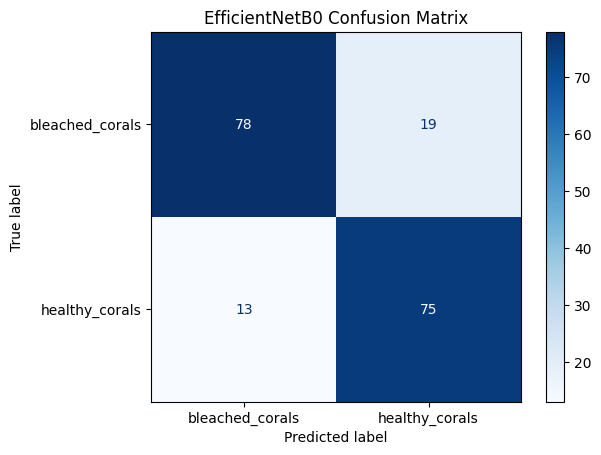


Classification Report for EfficientNetB0:
                 precision    recall  f1-score   support

bleached_corals       0.86      0.80      0.83        97
 healthy_corals       0.80      0.85      0.82        88

       accuracy                           0.83       185
      macro avg       0.83      0.83      0.83       185
   weighted avg       0.83      0.83      0.83       185



In [12]:
# ==============================================================
# 10. CONFUSION MATRIX & CLASSIFICATION REPORT
# ==============================================================
def evaluate_model(model, test_gen, model_name):
    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())
    y_pred = (model.predict(test_gen) > 0.5).astype(int).flatten()
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_labels))
evaluate_model(model_resnet, test_gen_resnet, "ResNet50")
evaluate_model(model_effnet, test_gen_effnet, "EfficientNetB0")

The classification reports reveal that EfficientNetB0 significantly outperforms ResNet50 in both overall performance and class balance. While ResNet50 shows a bias toward predicting healthy corals and struggles to correctly identify bleached corals (recall = 0.55), EfficientNetB0 achieves more balanced precision and recall across both classes. This results in higher F1-scores (~0.79–0.80) and improved reliability. From an application perspective, EfficientNetB0 is more suitable, as it reduces the risk of misclassifying bleached corals, which is critical for monitoring coral health.

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


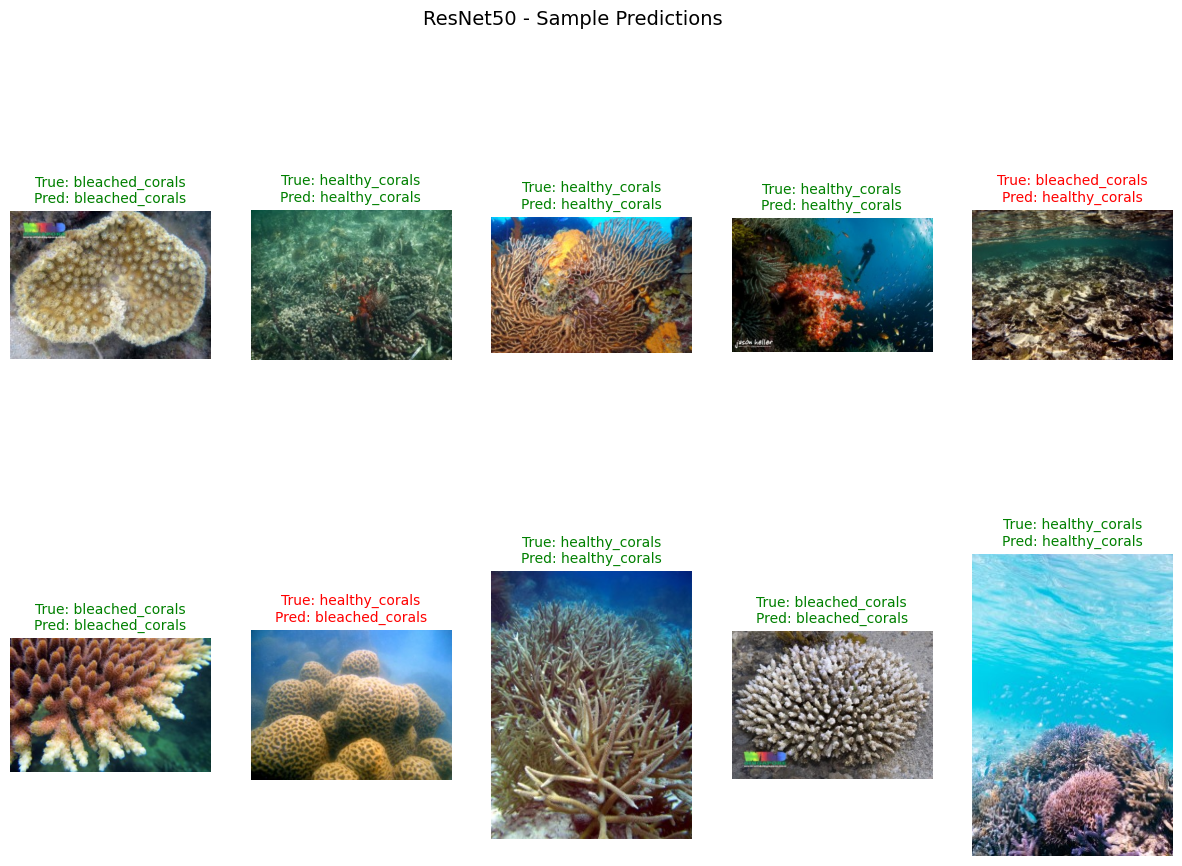

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 729ms/step


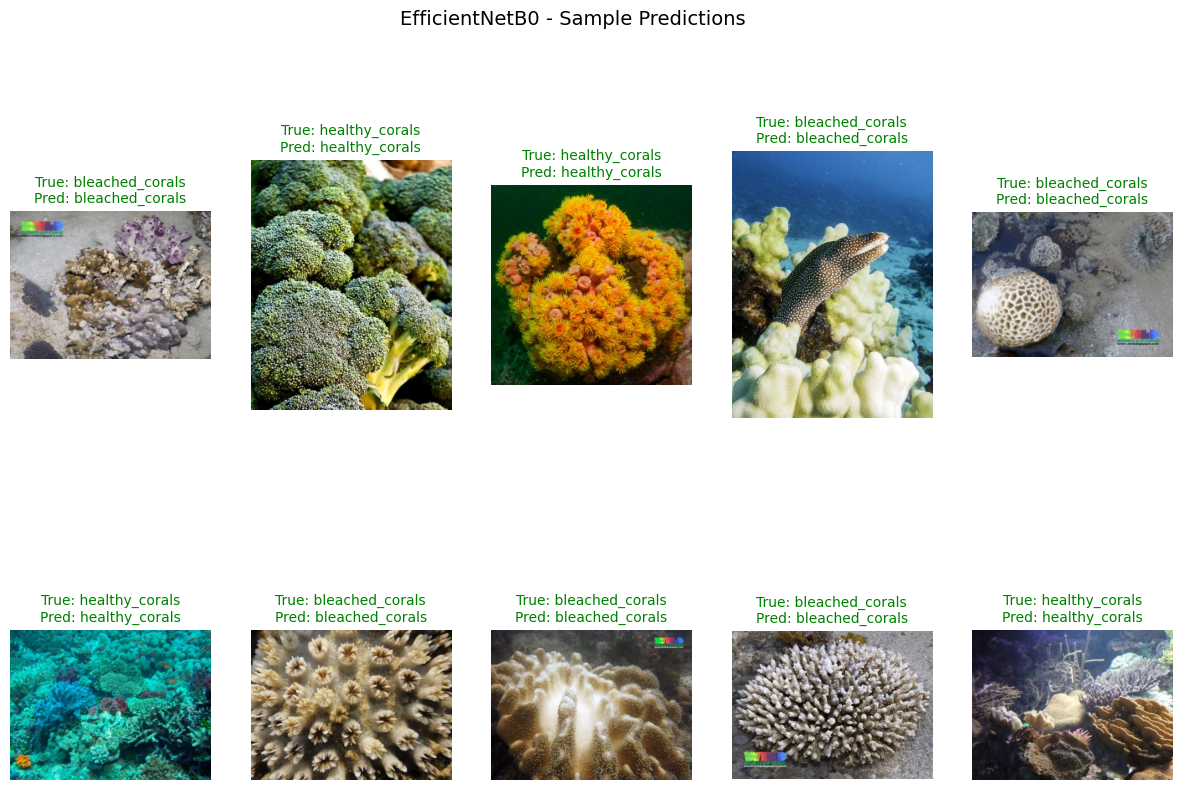

In [13]:
# ==============================================================
# 11. VISUALIZING SAMPLE PREDICTIONS
# ==============================================================

def show_predictions(model, test_gen, model_name, num_samples=10):
    # Get predictions
    test_gen.reset()
    preds = (model.predict(test_gen) > 0.5).astype(int).flatten()
    class_indices = {v: k for k, v in test_gen.class_indices.items()}

    # Collect filenames, true labels, and predicted labels
    filenames = test_gen.filenames
    true_labels = test_gen.classes
    pred_labels = preds

    # Pick random samples
    idxs = np.random.choice(range(len(filenames)), num_samples, replace=False)
    
    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(idxs):
        img_path = os.path.join(test_gen.directory, filenames[idx])
        img = Image.open(img_path)
        true_label = class_indices[true_labels[idx]]
        pred_label = class_indices[pred_labels[idx]]

        plt.subplot(2, num_samples//2, i+1)
        plt.imshow(img)
        color = "green" if true_label == pred_label else "red"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        plt.axis("off")

    plt.suptitle(f"{model_name} - Sample Predictions", fontsize=14)
    plt.show()

# Show results for both models
show_predictions(model_resnet, test_gen_resnet, "ResNet50", num_samples=10)
show_predictions(model_effnet, test_gen_effnet, "EfficientNetB0", num_samples=10)

In [15]:
# ==============================================================
# SAVE TRAINED MODEL
# ==============================================================

model_effnet.save("model_effnet.h5")
print("✅ EfficientNet model saved as model_effnet")

✅ EfficientNet model saved as model_effnet


In [2]:
from tensorflow.keras.models import load_model

model = load_model("model_effnet.h5", compile=False)
model.export("model_effnet_fixed")

INFO:tensorflow:Assets written to: model_effnet_fixed\assets


INFO:tensorflow:Assets written to: model_effnet_fixed\assets


Saved artifact at 'model_effnet_fixed'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2254509016848: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2254509017424: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2254509017616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2254509018000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2254509017808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2254509018768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2254509018192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2254509018384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2254509018960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2254509018576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2254509019728